## Lab 14 — Logistic Regression: From Scratch + Multiclass Extensions

### Instructions

In this lab, first implement **binary Logistic Regression from scratch** using a single parameter vector containing the intercept and feature weights. The design matrix is formed as $H=[\mathbf{1}\;X]$, so the model can be written compactly as:

$$z=H\theta$$

$$p=\sigma(z)=\frac{1}{1+e^{-z}}$$

The gradient for Binary Cross-Entropy is:

$$\nabla J=\frac{1}{m}H^T(p-y)$$

The parameters are updated together:

$$\theta\leftarrow\theta-\alpha\nabla J$$

The later **OvR and Softmax** sections use scikit-learn directly. They are included to demonstrate practical multiclass Logistic Regression; their algorithms are **not implemented from scratch** in this lab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

In [3]:
def plot_sigmoid():

    z = np.linspace(-8,8,400)
    p = sigmoid(z)
    plt.figure(figsize=(8,5))
    plt.plot(z,p,linewidth=3)
    plt.axvline(0,color="red",linestyle="--")
    plt.axhline(0.5,color="green",linestyle="--")
    plt.scatter([0],[0.5],s=80)
    plt.text(0.2, 0.53,"(z=0 , p=0.5)")

    plt.xlabel("Linear Score (z)")
    plt.ylabel("Probability")
    plt.title("Sigmoid Function")
    plt.grid(True)
    plt.show()

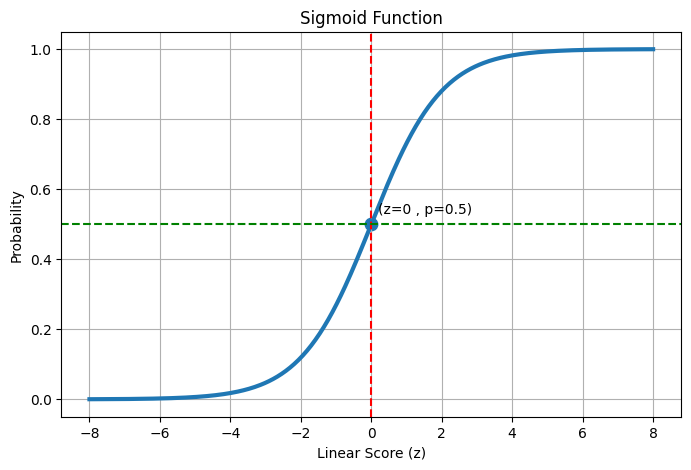

In [4]:
plot_sigmoid()

In [5]:
import os
import gdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [6]:
FILE_ID="1t5mmVocO1_fGXGqRftpekRom9yxq-ML4"
DATASET="student_clean_dataset.csv"

if not os.path.exists(DATASET):
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}",DATASET,quiet=False)

df=pd.read_csv(DATASET)

Downloading...
From: https://drive.google.com/uc?id=1t5mmVocO1_fGXGqRftpekRom9yxq-ML4
To: /content/student_clean_dataset.csv
100%|██████████| 19.1k/19.1k [00:00<00:00, 23.9MB/s]


In [7]:
df.head()

,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00
1,ST002,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00
2,ST003,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00
3,ST004,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39
4,ST005,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12


In [8]:
# convert placement
if df["Placement"].dtype==object:
    df["Placement"]=df["Placement"].map({
        "Placed":1,
        "Not Placed":0,
    })

print(df.head())
print(df["Placement"].value_counts())

  Student_ID  Age  Gender        Department  Study_Hours  Attendance  \
0      ST001   18    Male  Computer Science            3          98   
1      ST002   20    Male  Computer Science            1          81   
2      ST003   19    Male  Computer Science            3          76   
3      ST004   19  Female  Computer Science            5         100   
4      ST005   18  Female  Computer Science            5          68   

   Assignments  Exam_Score Result Grade  Placement   LPA  
0           12          60   Pass     B          0  0.00  
1           11          44   Pass     D          0  0.00  
2            9          46   Pass     D          0  0.00  
3           10          51   Pass     C          1  3.39  
4           13          54   Pass     C          1  3.12  
Placement
1    154
0    146
Name: count, dtype: int64


In [9]:
drop_cols=["Placement"]

for c in ["Student_ID","Result","Grade","LPA"]:
    if c in df.columns:
        drop_cols.append(c)

In [10]:
X=pd.get_dummies(df.drop(columns=drop_cols),drop_first=True)
feature_names=X.columns.tolist()
y=df["Placement"].astype(float).values
X=X.astype(float).values

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    random_state=42,
    stratify=y
)


In [12]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Step 12: Build the Design Matrix

Logistic Regression uses the same parameter-vector idea as the MLR lab.

The parameter vector stores the intercept and all feature weights together:

$$\theta = [b, w_1, w_2, \ldots, w_p]^T$$

The design matrix contains one leading column of ones:

$$H = [\mathbf{1}\; X]$$

We create `H` once for each dataset. The model functions then work directly with `H` and `theta`, so we do **not** repeatedly add `ones` and call `hstack` inside prediction and gradient functions.


In [13]:
def add_intercept(X):
    """Create the design matrix H = [1, X]."""
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))


H_train = add_intercept(X_train)
H_test = add_intercept(X_test)

print("H_train shape:", H_train.shape)
print("H_test shape:", H_test.shape)


H_train shape: (240, 10)
H_test shape: (60, 10)


In [14]:
# STUDENT TO-DO
# 1. Complete the sigmoid function.
# 2. Complete the Binary Cross-Entropy (BCE) loss calculation.
# 3. Complete the gradient calculation.
# 4. Complete the gradient descent algorithm.
# Do not change the function names or parameters.

def sigmoid(z):
    #TODO
    # return sig


def linear_score(H, theta):
    """Compute the linear score z = H @ theta."""
    #TODO
    # return z


def predict_probability(H, theta):
    """Compute sigmoid probabilities."""
    #TODO
    # return pp


def binary_cross_entropy(y, p):
    """Compute Binary Cross-Entropy loss."""
    #TODO
    # return bce


def compute_gradient(H, y, p):
    """Compute the gradient for the complete parameter vector."""
    # TODO
    # return (H.T @ error) / m


def gradient_descent(H, y, lr=0.1, epochs=100):
    """Train all Logistic Regression parameters together."""
    theta = np.zeros(H.shape[1])
    history = []

    for epoch in range(epochs):
        # TODO
        # Write your code here
        history.append(loss)
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1:4d} Loss={loss:.5f}")

    return theta, history


def predict(H, theta, threshold=0.5):
    """Return predicted class and probability."""
    p = predict_probability(H, theta)
    return (p >= threshold).astype(int), p


In [15]:
# -------------------------------------------------
# Train Main Model
# -------------------------------------------------
print("\nTraining Main Model...\n")

theta, loss_history = gradient_descent(
    H_train,
    y_train,
    lr=0.1,
    epochs=1000
)

bias = theta[0]
weights = theta[1:]

print("Final parameter vector shape:", theta.shape)
print("Bias:", bias)
print("Number of weights:", len(weights))



Training Main Model...

Epoch  100 Loss=0.42296
Epoch  200 Loss=0.41900
Epoch  300 Loss=0.41781
Epoch  400 Loss=0.41708
Epoch  500 Loss=0.41658
Epoch  600 Loss=0.41622
Epoch  700 Loss=0.41596
Epoch  800 Loss=0.41576
Epoch  900 Loss=0.41561
Epoch 1000 Loss=0.41550
Final parameter vector shape: (10,)
Bias: 0.008179883657456304
Number of weights: 9


In [16]:
# -------------------------------------------------
# Evaluation
# -------------------------------------------------
y_pred, prob = predict(H_test, theta)

print("\nEvaluation")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Evaluation
Accuracy : 0.7833333333333333
Precision: 0.8
Recall   : 0.7741935483870968
F1 Score : 0.7868852459016393
[[23  6]
 [ 7 24]]
              precision    recall  f1-score   support

         0.0       0.77      0.79      0.78        29
         1.0       0.80      0.77      0.79        31

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



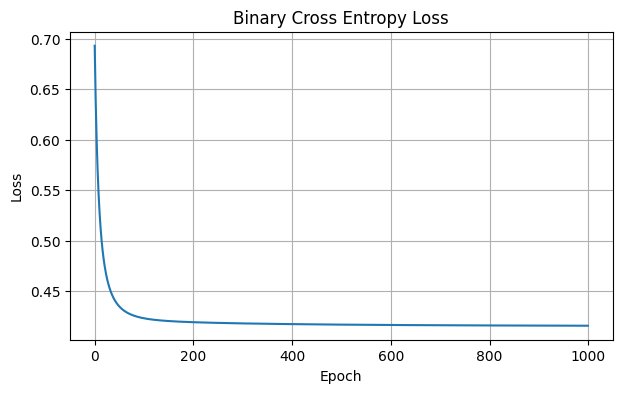

In [17]:
# -------------------------------------------------
# Loss Curve
# -------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.title("Binary Cross Entropy Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [18]:
X_vis = df[["Exam_Score"]].values
y_vis = df["Placement"].values

scaler_vis = StandardScaler()
X_vis = scaler_vis.fit_transform(X_vis)
H_vis = add_intercept(X_vis)

theta_vis, _ = gradient_descent(
    H_vis,
    y_vis,
    lr=0.1,
    epochs=1000
)


Epoch  100 Loss=0.46261
Epoch  200 Loss=0.44688
Epoch  300 Loss=0.44381
Epoch  400 Loss=0.44302
Epoch  500 Loss=0.44280
Epoch  600 Loss=0.44273
Epoch  700 Loss=0.44270
Epoch  800 Loss=0.44270
Epoch  900 Loss=0.44270
Epoch 1000 Loss=0.44269


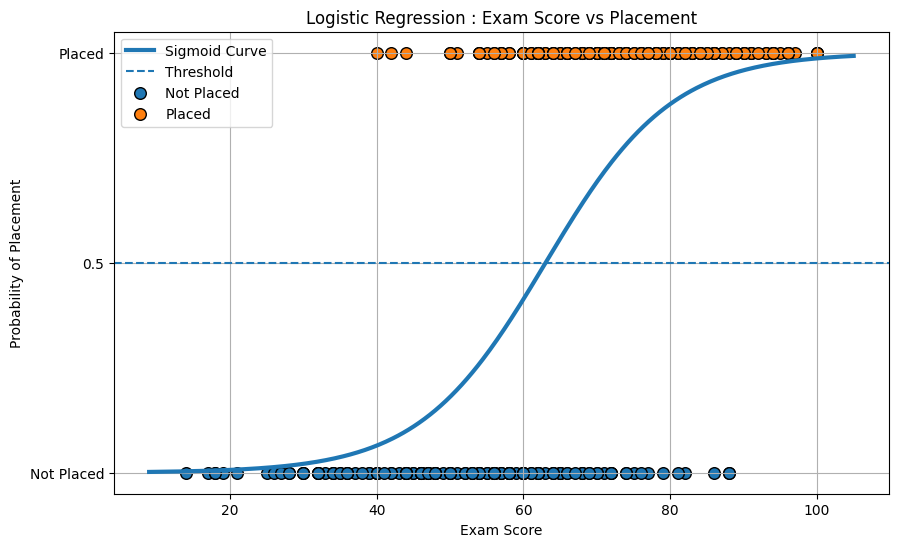

In [19]:
def plot_sigmoid_with_exam_score(df, theta, scaler):
    exam = df["Exam_Score"].values
    placement = df["Placement"].values

    x = np.linspace(exam.min() - 5, exam.max() + 5, 400)
    xs = scaler.transform(x.reshape(-1, 1))
    H_x = add_intercept(xs)
    p = predict_probability(H_x, theta)

    plt.figure(figsize=(10, 6))
    plt.plot(x, p, linewidth=3, label="Sigmoid Curve")
    plt.axhline(0.5, linestyle="--", label="Threshold")

    plt.scatter(
        exam[placement == 0],
        np.zeros(np.sum(placement == 0)),
        edgecolors="black",
        s=70,
        label="Not Placed"
    )

    plt.scatter(
        exam[placement == 1],
        np.ones(np.sum(placement == 1)),
        edgecolors="black",
        s=70,
        label="Placed"
    )

    plt.xlabel("Exam Score")
    plt.ylabel("Probability of Placement")
    plt.title("Logistic Regression : Exam Score vs Placement")
    plt.yticks([0, 0.5, 1], ["Not Placed", "0.5", "Placed"])
    plt.grid(True)
    plt.legend()
    plt.show()


plot_sigmoid_with_exam_score(df, theta_vis, scaler_vis)


In [20]:
print("\nLearned Parameters")
print(f"Intercept: {theta[0]:.4f}")

for name, coefficient in zip(feature_names, theta[1:]):
    print(f"{name:25s}: {coefficient:.4f}")



Learned Parameters
Intercept: 0.0082
Age                      : 0.0845
Study_Hours              : 1.3733
Attendance               : 0.2160
Assignments              : 0.5688
Exam_Score               : 0.4501
Gender_Male              : -0.0580
Department_Electronics   : -0.0086
Department_Information Technology: -0.0993
Department_Mechanical    : 0.0619


In [21]:
# New Student Prediction
# New student: Age, Study_Hours, Attendance, Assignments, Exam_Score,
# Gender_Male, Gender_Female, Department_CS, Department_IT

new_student = np.array([[21, 8, 90, 17, 85, 1, 0, 1, 0]])

# Scale using the already-fitted scaler.
new_student_scaled = scaler.transform(new_student)

# Build the design matrix once for the new observation.
H_new = add_intercept(new_student_scaled)

# Prediction using the complete parameter vector.
z = linear_score(H_new, theta)[0]
p = sigmoid(z)

print("Linear Score (z):", z)
print("Probability:", p)
print("Predicted Class:", "Placed" if p >= 0.5 else "Not Placed")


Linear Score (z): 2.889581828534494
Probability: 0.9473290200712046
Predicted Class: Placed


## Parameter Structure — Same Idea as MLR

The Logistic Regression implementation now follows the MLR parameter convention:

- `theta[0]` = intercept / bias
- `theta[1:]` = feature weights
- `theta` is updated as one vector
- `H` contains the intercept column and feature columns

Therefore, the core computation is simply:

$$z = H\theta$$

and the gradient is:

$$\nabla J = \frac{1}{m}H^T(p-y)$$

The intercept column is created once with `add_intercept()` rather than rebuilding `ones` and `hstack` inside every model function.

In [22]:
# ============================================================
# Likelihood and Log-Likelihood for Logistic Regression
# ============================================================

import numpy as np


# Sample data

y = np.array([1, 0, 1, 1, 0])

# Predicted probabilities from the logistic regression model
p = np.array([0.8, 0.3, 0.7, 0.9, 0.2])



# 1. Likelihood

def likelihood(y, p):
    """
    Compute the likelihood for binary logistic regression.
    L = Product[p_i^y_i * (1-p_i)^(1-y_i)]
    """

    # Avoid log/probability numerical issues
    p = np.clip(p, 1e-15, 1 - 1e-15)
    L = np.prod(p**y * (1 - p)**(1 - y))
    return L



# 2. Log-Likelihood

def log_likelihood(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    LL = np.sum(
        y * np.log(p)
        + (1 - y) * np.log(1 - p)
    )
    return LL

# 3. Calculate Likelihood

L = likelihood(y, p)
print("Likelihood:")
print(L)



# 4. Calculate Log-Likelihood

LL = log_likelihood(y, p)
print("\nLog-Likelihood:")
print(LL)



# 5. Verify the relationship

print("\nLog(Likelihood):")
print(np.log(L))

print("\nCheck:")
print("Log-Likelihood =", LL)
print("Log(Likelihood) =", np.log(L))


Likelihood:
0.28224

Log-Likelihood:
-1.2649975061637106

Log(Likelihood):
-1.2649975061637106

Check:
Log-Likelihood = -1.2649975061637106
Log(Likelihood) = -1.2649975061637106


## One-vs-Rest (OvR) and Softmax Multiclass Logistic Regression

For multiclass classification, we will use **scikit-learn implementations** rather than implementing OvR or Softmax from scratch.

- **OvR (One-vs-Rest):** trains one binary Logistic Regression classifier per class.
- **Softmax / Multinomial Logistic Regression:** learns all classes jointly.

The purpose of this section is to demonstrate how to use these approaches in practice.

### One-vs-Rest (OvR)

For $K$ classes, OvR trains $K$ binary classifiers. Class $k$ is treated as the positive class and all other classes are treated as the negative class.

Conceptually:

$$\text{Classifier}_k:\quad k\;\text{vs.}\;\text{all other classes}$$

The class with the strongest classifier result is selected as the final prediction. In this lab, OvR is provided by scikit-learn; **do not implement OvR from scratch**.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier


### 1. One-vs-Rest using scikit-learn

We explicitly use `OneVsRestClassifier` so that the OvR strategy is clear.

In [24]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load real dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Features:", iris.feature_names)
print("Classes:", iris.target_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Precision, Recall, and F1-Score

#### Precision
Precision tells us **how many of the samples predicted as a particular class were actually correct**.

$[
\text{Precision} = \frac{TP}{TP + FP}
]$

- **TP (True Positive):** Correctly predicted positive samples.
- **FP (False Positive):** Samples incorrectly predicted as positive.

**High precision** means the model makes fewer false-positive predictions.

---

#### Recall
Recall tells us **how many of the actual samples belonging to a class were correctly identified by the model**.

$[
\text{Recall} = \frac{TP}{TP + FN}
]$

- **TP (True Positive):** Correctly predicted positive samples.
- **FN (False Negative):** Positive samples incorrectly predicted as negative.

**High recall** means the model misses fewer actual positive samples.

---

#### F1-Score
F1-score combines **precision and recall** into a single metric using their harmonic mean.

$[
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
]$

F1-score is useful when we want a balance between **precision and recall**.

#### Example

If:

- Precision = 0.89
- Recall = 0.80

Then:

$[
F1 = 2 \times \frac{0.89 \times 0.80}{0.89 + 0.80}
\approx 0.84
]$

Therefore, the F1-score is approximately **0.84**.

In [26]:
# One-vs-Rest Logistic Regression
ovr_model = #TODO

ovr_model.fit(X_train_scaled, y_train)

y_pred_ovr = ovr_model.predict(X_test_scaled)

print("OvR Accuracy:", accuracy_score(y_test, y_pred_ovr))
print("OvR Classes:", ovr_model.classes_)

print("\nOvR Classification Report:")
print(classification_report(
    y_test,
    y_pred_ovr,
    target_names=iris.target_names
))

OvR Accuracy: 0.9
OvR Classes: [0 1 2]

OvR Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### 2. Softmax / Multinomial Logistic Regression using scikit-learn

For Softmax, scikit-learn's `LogisticRegression` can handle multiclass classification directly. We do not implement the Softmax function or its gradient manually.

### Softmax / Multinomial Logistic Regression

For a sample with $K$ classes, Softmax converts the class scores $z_k$ into probabilities:

$$P(y=k\mid x)=\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}}$$

The probabilities across all classes sum to 1. Here we use scikit-learn's multinomial Logistic Regression directly; **do not implement Softmax from scratch in this section**.

In [27]:
# Softmax / Multinomial Logistic Regression
softmax_model = #TODO
softmax_model.fit(X_train_scaled, y_train)

y_pred_softmax = softmax_model.predict(X_test_scaled)

print("Softmax Accuracy:", accuracy_score(y_test, y_pred_softmax))
print("Softmax Classes:", softmax_model.classes_)

print("\nSoftmax Classification Report:")
print(classification_report(
    y_test,
    y_pred_softmax,
    target_names=iris.target_names
))

Softmax Accuracy: 0.9333333333333333
Softmax Classes: [0 1 2]

Softmax Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [28]:
print("OvR Accuracy     :", accuracy_score(y_test, y_pred_ovr))
print("Softmax Accuracy :", accuracy_score(y_test, y_pred_softmax))

OvR Accuracy     : 0.9
Softmax Accuracy : 0.9333333333333333


### Practical Interpretation

For multiclass classification, both approaches produce a class prediction, but they use different modeling strategies.

- **OvR:** builds one binary classifier for each class against all remaining classes.
- **Softmax:** models all classes jointly and produces a probability distribution across the classes.

In this lab, both are demonstrated using scikit-learn rather than implementing the algorithms manually.

### OvR vs Softmax

| Approach | Idea | Implementation |
|---|---|---|
| OvR | One binary classifier per class | `OneVsRestClassifier(LogisticRegression(...))` |
| Softmax | All classes modeled jointly | `LogisticRegression(multi_class="multinomial")` |

**Important:** We use scikit-learn for both approaches; no OvR or Softmax algorithm is coded from scratch in this lab.